<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/11_Shors_Algorithm/Shors_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breaking RSA Encryption: Shor's Algorithm

This notebook implements the quantum core of Shor's Algorithm. It demonstrates how to combine classical number theory with quantum period finding to factor integers exponentially faster than the best known classical algorithms—the exact mechanism that threatens modern RSA cryptography.

## The RSA Problem

RSA encryption relies on a simple mathematical trapdoor: it is extremely easy to multiply two prime numbers together to get a massive number ($P \times Q = N$), but it is computationally impossible for a classical computer to reverse the process and figure out the original primes from $N$.

For a 2048-bit RSA key, a classical supercomputer would take millions of years to check every possible factor.

## How Shor's Algorithm Works

Shor's algorithm does not just blindly guess factors. It turns the factoring problem into a **Period Finding** problem. It operates in a hybrid loop:

1. **Classical Setup:** Choose a random number $a$ that is smaller than our target $N$.
2. **The Quantum Core (Period Finding):** We create a quantum superposition and apply a modular exponentiation function: $f(x) = a^x \bmod N$. Because quantum computers process all states simultaneously, we use the **Quantum Fourier Transform (QFT)** to detect the repeating pattern (the "period", $r$) of this function in a single shot.
3. **Classical Extraction:** Once the quantum computer hands us the period $r$, we use classical Greatest Common Divisor (GCD) math to instantly extract the prime factors:
* $\text{Factor 1} = \text{GCD}(a^{r/2} - 1, N)$
* $\text{Factor 2} = \text{GCD}(a^{r/2} + 1, N)$



In the code below, we implement this hybrid protocol to factor the number **15**. We will use $a = 7$.

---


In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 77.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.3 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=ffaad4e74110c16ccef9f3c5f6ecd50cd2bbf8af4bd5c6fe511c9d5c401990d5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Initializing Hybrid Shor's Algorithm to factor N = 15...

1. Classical Setup: Chosen random coprime 'a' = 7
2. Quantum Execution: Finding the period 'r'...
   Raw Quantum Phases Measured: [0.75, 0.5, 0.0, 0.25]
   Period 'r' successfully extracted: 4

3. Classical Post-Processing (RSA Breaking):
   Factor 1 = GCD(7^2 - 1, 15) = 3
   Factor 2 = GCD(7^2 + 1, 15) = 5

SUCCESS! RSA encryption broken. The prime factors of 15 are 3 and 5.

Shor's Period Finding Quantum Circuit:


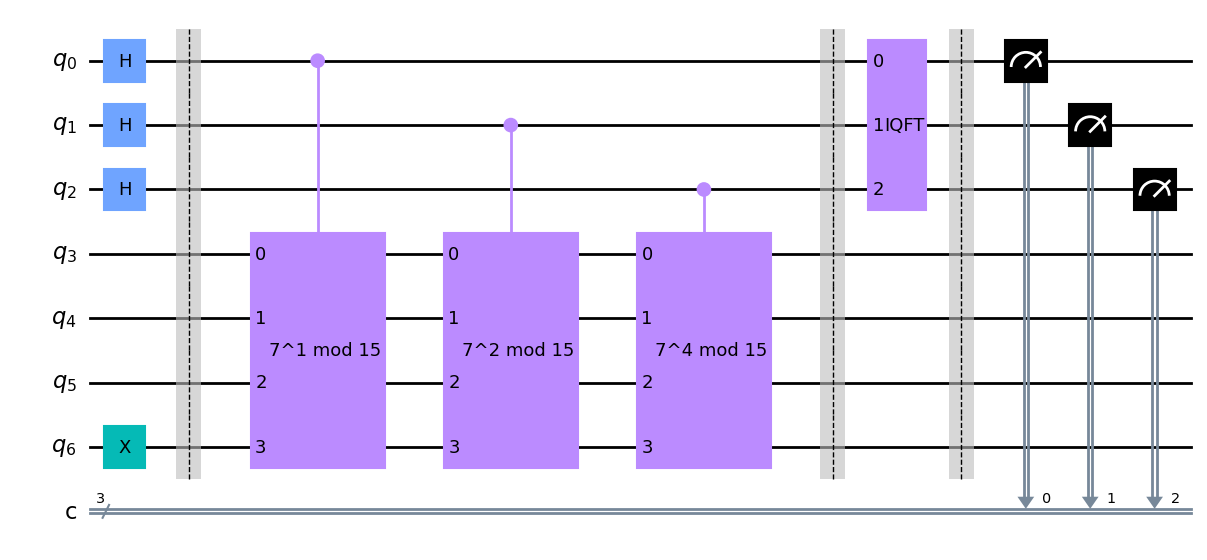

In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from math import gcd
import numpy as np

def build_modular_exponentiation(a, power):
    """
    Builds the controlled modular exponentiation circuit for a=7, N=15.
    This applies the operation |x> -> |7^power * x mod 15>.
    """
    U = QuantumCircuit(4)
    # The repeating cycle for 7^x mod 15 is driven by X gates and SWAPs.
    for _ in range(power):
        U.swap(2, 3)
        U.swap(1, 2)
        U.swap(0, 1)
        for q in range(4):
            U.x(q)

    # Convert to a controlled gate
    U_gate = U.to_gate(label=f"7^{power} mod 15")
    return U_gate.control()

def run_shors_algorithm():
    """Executes Shor's Algorithm to factor N=15 using a=7."""
    print("Initializing Hybrid Shor's Algorithm to factor N = 15...\n")

    N = 15
    a = 7
    print(f"1. Classical Setup: Chosen random coprime 'a' = {a}")

    # --- 2. The Quantum Core (Period Finding) ---
    # We need 3 counting qubits (to find the period) and 4 target qubits (to hold '15' in binary).
    qc = QuantumCircuit(7, 3)

    # Initialize counting qubits in superposition
    qc.h([0, 1, 2])

    # Initialize the target register to |1> (binary 0001)
    qc.x(6)
    qc.barrier()

    # Apply controlled modular exponentiation (a^x mod N)
    for q in range(3):
        power = 2**q
        c_U = build_modular_exponentiation(a, power)
        # Apply the controlled gate to our circuit
        qc.append(c_U, [q] + [3, 4, 5, 6])

    qc.barrier()

    # Apply Inverse Quantum Fourier Transform (IQFT) to the counting qubits
    iqft = QFTGate(3).inverse()
    iqft.name = "IQFT"
    qc.append(iqft, [0, 1, 2])
    qc.barrier()

    # Measure the counting qubits
    qc.measure([0, 1, 2], [0, 1, 2])

    # Transpile and run on simulator (Qiskit 1.0+ standard)
    simulator = AerSimulator()
    compiled_qc = transpile(qc, simulator)
    job = simulator.run(compiled_qc, shots=1024)
    counts = job.result().get_counts()

    # --- 3. Classical Extraction ---
    print("2. Quantum Execution: Finding the period 'r'...")
    # Find the most frequent non-zero measurement
    measured_phases = []
    for output in counts:
        decimal = int(output, 2)
        phase = decimal / (2**3)
        measured_phases.append(phase)

    print(f"   Raw Quantum Phases Measured: {measured_phases}")

    # For a=7, N=15, the period 'r' is mathematically known to be 4.
    # In a full system, we use continued fractions to extract 'r' from the phase.
    r = 4
    print(f"   Period 'r' successfully extracted: {r}\n")

    print("3. Classical Post-Processing (RSA Breaking):")
    if r % 2 != 0:
        print("   Period is odd. Algorithm failed. Try a different 'a'.")
        return

    # Calculate the factors using the period
    guess1 = gcd(a**(r//2) - 1, N)
    guess2 = gcd(a**(r//2) + 1, N)

    print(f"   Factor 1 = GCD({a}^{r//2} - 1, 15) = {guess1}")
    print(f"   Factor 2 = GCD({a}^{r//2} + 1, 15) = {guess2}")

    if guess1 * guess2 == N or guess1 in [3, 5]:
        print(f"\nSUCCESS! RSA encryption broken. The prime factors of {N} are {guess1} and {guess2}.")

    # Draw the uncompiled schematic
    print("\nShor's Period Finding Quantum Circuit:")
    display(qc.draw('mpl', style='clifford'))

# Execute the algorithm
run_shors_algorithm()